# Sigmoid experiment

## Generate N * d data manifold X - either Pareto, Cauchy or Uniform
## Calculate PP(X)
## Apply Sigmoid
## Calculate PP(Sigmoid(X))

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from scipy.linalg import qr

import math
import pandas as pd

In [2]:
import PatnaikPearson as pp
import cupy

In [3]:
this_N = 1000
this_d = 1000

min_alpha = 0.1
max_alpha = 10.0
scale_factor = max_alpha - min_alpha
num_iterations = 100

alpha_X_vals = np.zeros(num_iterations)
actual_alpha_X_vals = np.zeros(num_iterations)
actual_alpha_sigmoidX_vals = np.zeros(num_iterations)
pp_dim_X_vals = np.zeros(num_iterations)
pp_dim_sigmoidX_vals = np.zeros(num_iterations)
nu_over_d_X_vals = np.zeros(num_iterations)
nu_over_d_sigmoidX_vals = np.zeros(num_iterations)

for i in range(0, num_iterations):
  this_alpha_X = min_alpha + scale_factor * (i / (num_iterations - 1))**1.5
  results_dict = pp.sigmoid_experiment(this_N, this_d, this_alpha_X, generate_weight_matrix = True, pareto_uniform_draws = True, use_pareto = True)
  alpha_X_vals[i] = this_alpha_X
  actual_alpha_X_vals[i] = results_dict["actual_alpha_X"]
  actual_alpha_sigmoidX_vals[i] = results_dict["actual_alpha_sigmoidX"]
  pp_dim_X_vals[i] = results_dict["pp_dim_X"]
  pp_dim_sigmoidX_vals[i] = results_dict["pp_dim_sigmoidX"]
  nu_over_d_X_vals[i] = results_dict["nu_over_d_X"]
  nu_over_d_sigmoidX_vals[i] = results_dict["nu_over_d_sigmoidX"]
  print(i, this_alpha_X, results_dict["actual_alpha_X"], results_dict["actual_alpha_sigmoidX"], results_dict["nu_over_d_X"], results_dict["nu_over_d_sigmoidX"])

 ** generate_square_weight_matrix: using GPU **
0 0.1 0.29324448541265263 0.35664159432558207 0.00100198801573119 0.0014159729021207721
 ** generate_square_weight_matrix: using GPU **
1 0.11005037815259212 0.2935602154460267 0.4327612914354241 0.0010037779041035303 0.0021074156333018537
 ** generate_square_weight_matrix: using GPU **
2 0.12842676218074806 0.29456574141252595 0.49826995919469724 0.001009494299413214 0.0029667985063123407
 ** generate_square_weight_matrix: using GPU **
3 0.15222329678670937 0.2968965142405811 0.5577074249942017 0.0010228391206580768 0.004077603944164414
 ** generate_square_weight_matrix: using GPU **
4 0.18040302522073698 0.3013911863447641 0.6686000681894961 0.001048951413784894 0.007585715243118125
 ** generate_square_weight_matrix: using GPU **
5 0.2123666437438737 0.3087723070144464 0.7352918977710658 0.0010929441728610998 0.011155586401838306
 ** generate_square_weight_matrix: using GPU **
6 0.2477097891751993 0.3197900305294865 0.8170292631999359 0

KeyboardInterrupt: 

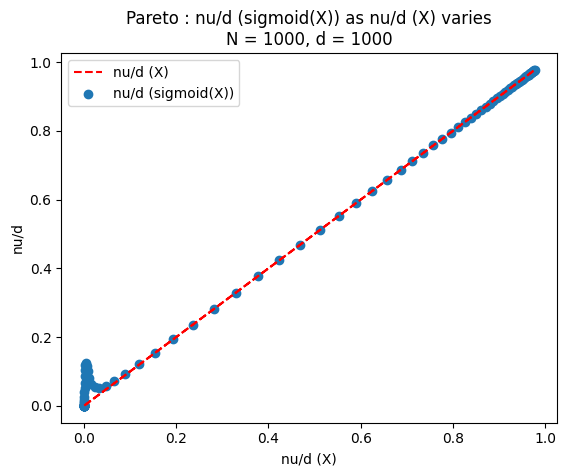

In [7]:
this_title = "Pareto : nu/d (sigmoid(X)) as nu/d (X) varies\n"
this_title += "N = " + str(this_N) + ", d = " + str(this_d)
plt.plot(nu_over_d_X_vals, nu_over_d_X_vals, linestyle = "--", label = "nu/d (X)", color = "red")
plt.scatter(nu_over_d_X_vals, nu_over_d_sigmoidX_vals, label = "nu/d (sigmoid(X))")
plt.xlabel("nu/d (X)")
plt.ylabel("nu/d")
plt.legend()
plt.title(this_title)
#plt.savefig('nu_over_d_sigmoid_X_vs_nu_over_d_X_pareto.pdf', dpi=300, bbox_inches='tight')
plt.savefig('nu_over_d_sigmoid_W_vs_nu_over_d_W_pareto.pdf', dpi=300, bbox_inches='tight')
plt.show()

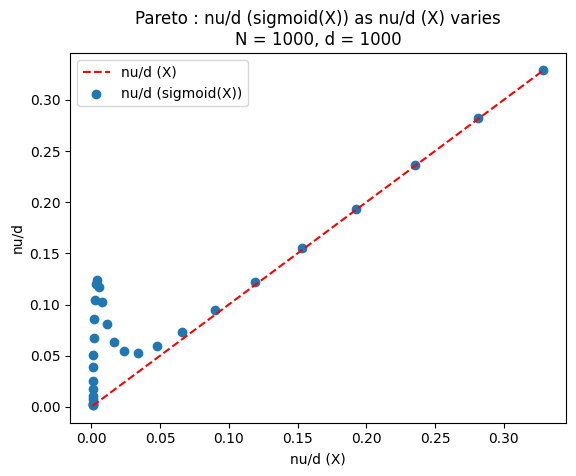

In [10]:
k= 30
this_title = "Pareto : nu/d (sigmoid(X)) as nu/d (X) varies\n"
this_title += "N = " + str(this_N) + ", d = " + str(this_d)
plt.plot(nu_over_d_X_vals[0:k], nu_over_d_X_vals[0:k], linestyle = "--", label = "nu/d (X)", color = "red")
plt.scatter(nu_over_d_X_vals[0:k], nu_over_d_sigmoidX_vals[0:k], label = "nu/d (sigmoid(X))")
plt.xlabel("nu/d (X)")
plt.ylabel("nu/d")
plt.legend()
plt.title(this_title)
#plt.savefig('nu_over_d_sigmoid_X_vs_nu_over_d_X_pareto.pdf', dpi=300, bbox_inches='tight')
#plt.savefig('nu_over_d_sigmoid_W_vs_nu_over_d_W_pareto_two.pdf', dpi=300, bbox_inches='tight')
plt.show()

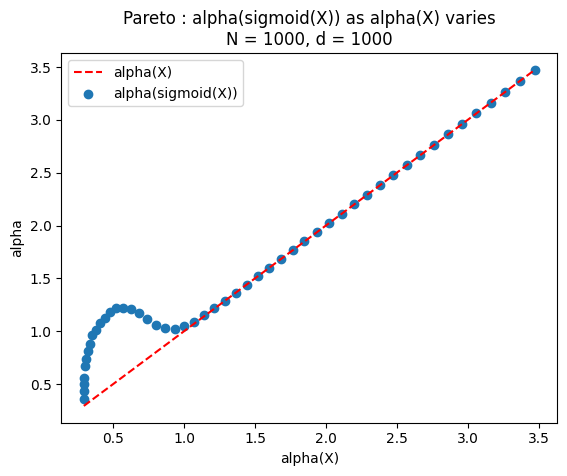

In [14]:
k= 50
this_title = "Pareto : alpha(sigmoid(X)) as alpha(X) varies\n"
this_title += "N = " + str(this_N) + ", d = " + str(this_d)
plt.plot(actual_alpha_X_vals[0:k], actual_alpha_X_vals[0:k], linestyle = "--", label = "alpha(X)", color = "red")
plt.scatter(actual_alpha_X_vals[0:k], actual_alpha_sigmoidX_vals[0:k], label = "alpha(sigmoid(X))")
plt.xlabel("alpha(X)")
plt.ylabel("alpha")
plt.legend()
plt.title(this_title)
#plt.savefig('alpha_sigmoid_X_vs_alpha_X_pareto.pdf', dpi=300, bbox_inches='tight')
plt.savefig('alpha_sigmoid_W_vs_alpha_W_pareto.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Now for uniform

In [15]:
this_N = 1000
this_d = 1000

min_alpha = 0.1
max_alpha = 10.0
scale_factor = max_alpha - min_alpha
num_iterations = 20

alpha_X_vals = np.zeros(num_iterations)
actual_alpha_X_vals = np.zeros(num_iterations)
actual_alpha_sigmoidX_vals = np.zeros(num_iterations)
pp_dim_X_vals = np.zeros(num_iterations)
pp_dim_sigmoidX_vals = np.zeros(num_iterations)
nu_over_d_X_vals = np.zeros(num_iterations)
nu_over_d_sigmoidX_vals = np.zeros(num_iterations)

for i in range(0, num_iterations):
  this_alpha_X = min_alpha + scale_factor * (i / (num_iterations - 1))**1.5
  results_dict = pp.sigmoid_experiment(this_N, this_d, this_alpha_X, generate_weight_matrix = True, 
                                           pareto_uniform_draws = False, 
                                           use_pareto = False,
                                           use_uniform = True)
  alpha_X_vals[i] = this_alpha_X
  actual_alpha_X_vals[i] = results_dict["actual_alpha_X"]
  actual_alpha_sigmoidX_vals[i] = results_dict["actual_alpha_sigmoidX"]
  pp_dim_X_vals[i] = results_dict["pp_dim_X"]
  pp_dim_sigmoidX_vals[i] = results_dict["pp_dim_sigmoidX"]
  nu_over_d_X_vals[i] = results_dict["nu_over_d_X"]
  nu_over_d_sigmoidX_vals[i] = results_dict["nu_over_d_sigmoidX"]
  print(i, this_alpha_X, results_dict["actual_alpha_X"], results_dict["actual_alpha_sigmoidX"], results_dict["nu_over_d_X"], results_dict["nu_over_d_sigmoidX"])

 ** generate_square_weight_matrix: using GPU **
0 0.1 2.624876521019996 2.62487635558199 0.7486812404672999 0.7486812034614919
 ** generate_square_weight_matrix: using GPU **
1 0.21953767185887163 2.6410393807881594 2.64103987842578 0.7522624849259385 0.7522625941451889
 ** generate_square_weight_matrix: using GPU **
2 0.4381035935146419 2.626129578917065 2.6261298672209197 0.7489613228278432 0.7489613872217818
 ** generate_square_weight_matrix: using GPU **
3 0.7211359632341863 2.697936806215935 2.6979368821962746 0.7643429246568766 0.7643429402583979
 ** generate_square_weight_matrix: using GPU **
4 1.056301374870973 2.6456310829437273 2.6456311745008474 0.7532675399506105 0.7532675599371396
 ** generate_square_weight_matrix: using GPU **
5 1.4364718007425035 2.6249244105759066 2.62492489352817 0.7486919522841828 0.7486920603066727
 ** generate_square_weight_matrix: using GPU **
6 1.8568378065669249 2.6212506613487454 2.6212506788952803 0.7478684625112377 0.7478684664528882
 ** gener

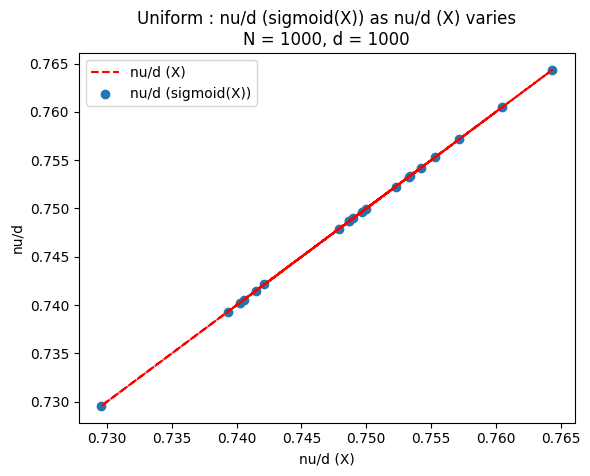

In [17]:
k= 30
this_title = "Uniform : nu/d (sigmoid(X)) as nu/d (X) varies\n"
this_title += "N = " + str(this_N) + ", d = " + str(this_d)
plt.plot(nu_over_d_X_vals[0:k], nu_over_d_X_vals[0:k], linestyle = "--", label = "nu/d (X)", color = "red")
plt.scatter(nu_over_d_X_vals[0:k], nu_over_d_sigmoidX_vals[0:k], label = "nu/d (sigmoid(X))")
plt.xlabel("nu/d (X)")
plt.ylabel("nu/d")
plt.legend()
plt.title(this_title)
#plt.savefig('nu_over_d_sigmoid_X_vs_nu_over_d_X_pareto.pdf', dpi=300, bbox_inches='tight')
#plt.savefig('nu_over_d_sigmoid_W_vs_nu_over_d_W_uniform.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Finally Cauchy

In [19]:
this_N = 1000
this_d = 1000

min_alpha = 0.1
max_alpha = 10.0
scale_factor = max_alpha - min_alpha
num_iterations = 20

alpha_X_vals = np.zeros(num_iterations)
actual_alpha_X_vals = np.zeros(num_iterations)
actual_alpha_sigmoidX_vals = np.zeros(num_iterations)
pp_dim_X_vals = np.zeros(num_iterations)
pp_dim_sigmoidX_vals = np.zeros(num_iterations)
nu_over_d_X_vals = np.zeros(num_iterations)
nu_over_d_sigmoidX_vals = np.zeros(num_iterations)

for i in range(0, num_iterations):
  this_alpha_X = min_alpha + scale_factor * (i / (num_iterations - 1))**1.5
  results_dict = pp.sigmoid_experiment(this_N, this_d, this_alpha_X, generate_weight_matrix = True, 
                                           pareto_uniform_draws = False, 
                                           use_pareto = False,
                                           use_uniform = False,
                                           use_cauchy = True)
  alpha_X_vals[i] = this_alpha_X
  actual_alpha_X_vals[i] = results_dict["actual_alpha_X"]
  actual_alpha_sigmoidX_vals[i] = results_dict["actual_alpha_sigmoidX"]
  pp_dim_X_vals[i] = results_dict["pp_dim_X"]
  pp_dim_sigmoidX_vals[i] = results_dict["pp_dim_sigmoidX"]
  nu_over_d_X_vals[i] = results_dict["nu_over_d_X"]
  nu_over_d_sigmoidX_vals[i] = results_dict["nu_over_d_sigmoidX"]
  print(i, this_alpha_X, results_dict["actual_alpha_X"], results_dict["actual_alpha_sigmoidX"], results_dict["nu_over_d_X"], results_dict["nu_over_d_sigmoidX"])

 ** generate_square_weight_matrix: using GPU **
0 0.1 0.5183455238114343 0.7207195414474266 0.003299723375366395 0.010250688267403484
 ** generate_square_weight_matrix: using GPU **
1 0.21953767185887163 0.9630080035615065 0.9892313946201132 0.03966274012912409 0.045284408305813914
 ** generate_square_weight_matrix: using GPU **
2 0.4381035935146419 0.7706480732112352 0.8795449420415818 0.013695522361001449 0.025419843935447443
 ** generate_square_weight_matrix: using GPU **
3 0.7211359632341863 0.6959436644854128 0.8799568908226775 0.008880060941908147 0.025477655308683483
 ** generate_square_weight_matrix: using GPU **
4 1.056301374870973 0.8332404628419339 0.9447690848535533 0.01961604982548356 0.03609143902840493
 ** generate_square_weight_matrix: using GPU **
5 1.4364718007425035 0.9591255562571513 0.9899103888385764 0.03887970019362608 0.045437808145589405
 ** generate_square_weight_matrix: using GPU **
6 1.8568378065669249 0.8077919088162595 0.88341135445541 0.016965908650982922

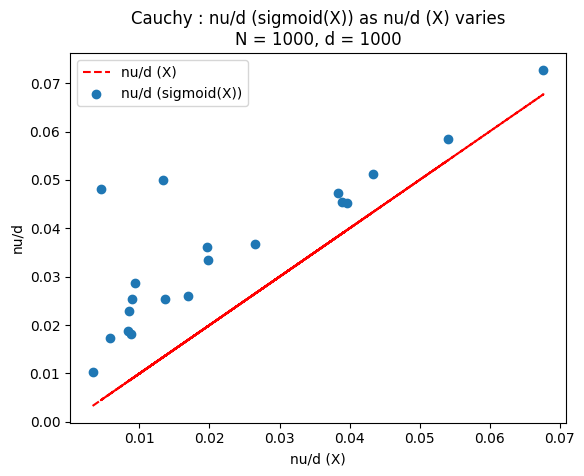

In [20]:
k= 30
this_title = "Cauchy : nu/d (sigmoid(X)) as nu/d (X) varies\n"
this_title += "N = " + str(this_N) + ", d = " + str(this_d)
plt.plot(nu_over_d_X_vals[0:k], nu_over_d_X_vals[0:k], linestyle = "--", label = "nu/d (X)", color = "red")
plt.scatter(nu_over_d_X_vals[0:k], nu_over_d_sigmoidX_vals[0:k], label = "nu/d (sigmoid(X))")
plt.xlabel("nu/d (X)")
plt.ylabel("nu/d")
plt.legend()
plt.title(this_title)
#plt.savefig('nu_over_d_sigmoid_X_vs_nu_over_d_X_pareto.pdf', dpi=300, bbox_inches='tight')
#plt.savefig('nu_over_d_sigmoid_W_vs_nu_over_d_W_cauchy.pdf', dpi=300, bbox_inches='tight')
plt.show()

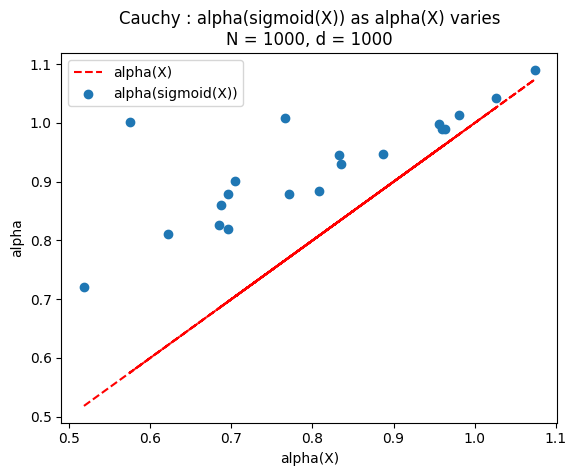

In [21]:
k= 50
this_title = "Cauchy : alpha(sigmoid(X)) as alpha(X) varies\n"
this_title += "N = " + str(this_N) + ", d = " + str(this_d)
plt.plot(actual_alpha_X_vals[0:k], actual_alpha_X_vals[0:k], linestyle = "--", label = "alpha(X)", color = "red")
plt.scatter(actual_alpha_X_vals[0:k], actual_alpha_sigmoidX_vals[0:k], label = "alpha(sigmoid(X))")
plt.xlabel("alpha(X)")
plt.ylabel("alpha")
plt.legend()
plt.title(this_title)
#plt.savefig('alpha_sigmoid_X_vs_alpha_X_pareto.pdf', dpi=300, bbox_inches='tight')
#plt.savefig('alpha_sigmoid_W_vs_alpha_W_cauchy.pdf', dpi=300, bbox_inches='tight')
plt.show()